In [ ]:
import os
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# --- 1. KONFIGURASI PATH & HYPERPARAMETER ---
DATASET_PATH = 'master_dataset/dataset_jenis_buah'
TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
TEST_DIR = os.path.join(DATASET_PATH, 'test')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

# --- 2. DYNAMIC DATA PIPELINE (ON-THE-FLY PREPROCESSING) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Test generator hanya melakukan rescaling tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# --- 3. ARSITEKTUR MOBILENETV2 (TRANSFER LEARNING) ---
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers untuk fase awal

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax') # 3 Kelas: Apple, Banana, Orange
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 4. AUTOMATED CALLBACKS ---
if not os.path.exists('models'):
    os.makedirs('models')

checkpoint = ModelCheckpoint(
    'models/model_variety_best.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# --- 5. TRAINING EXECUTION ---
print("\n[INFO] Memulai Training Model 1 pada GPU Metal...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

print("\n[INFO] Training Selesai. Model terbaik disimpan di: models/model_variety_best.h5")

Found 6308 images belonging to 3 classes.
Found 1505 images belonging to 3 classes.


2026-05-02 09:39:36.524730: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-02 09:39:36.524904: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-02 09:39:36.524914: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-02 09:39:36.524949: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-02 09:39:36.524969: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

[INFO] Memulai Training Model 1 pada GPU Metal...
Epoch 1/20


2026-05-02 09:39:40.965509: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5688 - loss: 0.9615
Epoch 1: val_accuracy improved from None to 0.84850, saving model to models/model_variety_best.h5


...


Epoch 9: finished saving model to models/model_variety_best.h5
198/198 ━━━━━━━━━━━━━━━━━━━━ 60s 304ms/step - accuracy: 0.9516 - loss: 0.1392 - val_accuracy: 0.9701 - val_loss: 0.1101
Epoch 10/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9480 - loss: 0.1384
Epoch 10: val_accuracy improved from 0.97010 to 0.97076, saving model to models/model_variety_best.h5



Epoch 10: finished saving model to models/model_variety_best.h5
198/198 ━━━━━━━━━━━━━━━━━━━━ 55s 276ms/step - accuracy: 0.9499 - loss: 0.1314 - val_accuracy: 0.9708 - val_loss: 0.1045
Epoch 11/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9537 - loss: 0.1284
Epoch 11: val_accuracy did not improve from 0.97076
198/198 ━━━━━━━━━━━━━━━━━━━━ 54s 270ms/step - accuracy: 0.9561 - loss: 0.1263 - val_accuracy: 0.9708 - val_loss: 0.1041
Epoch 12/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9614 - loss: 0.1126
Epoch 12: val_accuracy improved from 0.97076 to 0.97143, saving model to models/model_variety_best.h5



Epoch 12: finished saving model to models/model_variety_best.h5
198/198 ━━━━━━━━━━━━━━━━━━━━ 54s 273ms/step - accuracy: 0.9570 - loss: 0.1202 - val_accuracy: 0.9714 - val_loss: 0.0994
Epoch 13/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9608 - loss: 0.1136
Epoch 13: val_accuracy improved from 0.97143 to 0.97209, saving model to models/model_variety_best.h5



Epoch 13: finished saving model to models/model_variety_best.h5
198/198 ━━━━━━━━━━━━━━━━━━━━ 56s 280ms/step - accuracy: 0.9608 - loss: 0.1104 - val_accuracy: 0.9721 - val_loss: 0.0955
Epoch 14/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9646 - loss: 0.1025
Epoch 14: val_accuracy did not improve from 0.97209
198/198 ━━━━━━━━━━━━━━━━━━━━ 55s 276ms/step - accuracy: 0.9643 - loss: 0.1028 - val_accuracy: 0.9721 - val_loss: 0.0915
Epoch 15/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9620 - loss: 0.1029
Epoch 15: val_accuracy improved from 0.97209 to 0.97475, saving model to models/model_variety_best.h5



Epoch 15: finished saving model to models/model_variety_best.h5
198/198 ━━━━━━━━━━━━━━━━━━━━ 61s 306ms/step - accuracy: 0.9621 - loss: 0.1063 - val_accuracy: 0.9748 - val_loss: 0.0866
Epoch 16/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9661 - loss: 0.0982
Epoch 16: val_accuracy did not improve from 0.97475
198/198 ━━━━━━━━━━━━━━━━━━━━ 60s 300ms/step - accuracy: 0.9646 - loss: 0.0990 - val_accuracy: 0.9734 - val_loss: 0.0868
Epoch 17/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9701 - loss: 0.0921
Epoch 17: val_accuracy did not improve from 0.97475
198/198 ━━━━━━━━━━━━━━━━━━━━ 59s 298ms/step - accuracy: 0.9662 - loss: 0.0977 - val_accuracy: 0.9741 - val_loss: 0.0828
Epoch 18/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9663 - loss: 0.0892
Epoch 18: val_accuracy did not improve from 0.97475
198/198 ━━━━━━━━━━━━━━━━━━━━ 57s 285ms/step - accuracy: 0.9675 - loss: 0.0907 - val_accuracy: 0.9741 - val_loss: 0.0827
Epoch 19/20
198/198 ━━━━━━━━━━━━

In [ ]:
#UNTUK MENYIMPAN DAN MEMUAT LAGI MODEL KE RAM

import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. DEFINISIKAN ULANG VARIABEL KONFIGURASI ---

TEST_DIR = 'master_dataset/dataset_jenis_buah/test' 
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- 2. HIDUPKAN ULANG TEST_DATAGEN ---
test_datagen = ImageDataGenerator(rescale=1./255)

# --- 3. HIDUPKAN ULANG TEST_GENERATOR ---
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

# --- 4. MUAT KEMBALI MODEL KE RAM ---
MODEL_PATH = 'models/model_variety_best.h5'
if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)
    print("\n[SUCCESS] Semua variabel (test_datagen, TEST_DIR, model, dll) sudah AKTIF kembali!")
else:
    print(f"\n[ERROR] File {MODEL_PATH} tidak ditemukan. Cek folder 'models' kamu.")

Found 1505 images belonging to 3 classes.


2026-05-02 17:34:18.130995: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-02 17:34:18.131352: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-02 17:34:18.131361: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-02 17:34:18.131663: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-02 17:34:18.131685: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



[SUCCESS] Semua variabel (test_datagen, TEST_DIR, model, dll) sudah AKTIF kembali!


[INFO] Mengonfigurasi ulang test generator...
Found 1505 images belonging to 3 classes.
[INFO] Melakukan prediksi pada dataset test...
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step


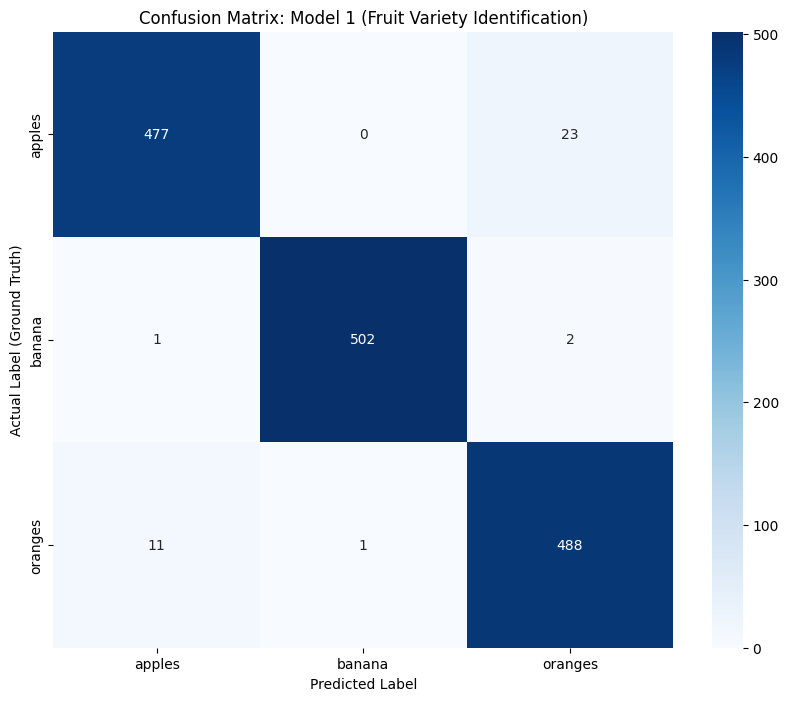


HASIL EVALUASI PERFORMA MODEL 1
              precision    recall  f1-score   support

      apples     0.9755    0.9540    0.9646       500
      banana     0.9980    0.9941    0.9960       505
     oranges     0.9513    0.9760    0.9635       500

    accuracy                         0.9748      1505
   macro avg     0.9749    0.9747    0.9747      1505
weighted avg     0.9750    0.9748    0.9748      1505

Total Accuracy (Global): 97.48%


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. REDEFINISI TEST GENERATOR (PENTING) ---
print("[INFO] Mengonfigurasi ulang test generator...")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  
)

# --- 2. PROSES INFERENSI ---
print("[INFO] Melakukan prediksi pada dataset test...")
test_generator.reset()
Y_pred = model.predict(test_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- 3. GENERATE CONFUSION MATRIX  ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('Confusion Matrix: Model 1 (Fruit Variety Identification)')
plt.ylabel('Actual Label (Ground Truth)')
plt.xlabel('Predicted Label')
plt.show()

# --- 4. CALCULATE STATISTICAL METRICS ---
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)

print("\n" + "="*60)
print("HASIL EVALUASI PERFORMA MODEL 1")
print("="*60)
print(report)

overall_accuracy = accuracy_score(y_true, y_pred)
print(f"Total Accuracy (Global): {overall_accuracy * 100:.2f}%")
print("="*60)

In [7]:
#SIMPAN JSON
import json

# Mengambil mapping asli {label: index}
class_indices = test_generator.class_indices

# Membalik mapping menjadi {index: label} agar mudah dibaca sistem
labels_map = {v: k for k, v in class_indices.items()}

# Simpan ke folder models
json_path = 'models/class_indices_variety.json'
with open(json_path, 'w') as f:
    json.dump(labels_map, f, indent=4)

print(f"[SUCCESS] Label map disimpan di: {json_path}")
print("Isi Label Map:", labels_map)

[SUCCESS] Label map disimpan di: models/class_indices_variety.json
Isi Label Map: {0: 'apples', 1: 'banana', 2: 'oranges'}


In [8]:
#BENCHMARKING TIME
import time

def benchmark_inference(num_trials=50):
    # Ambil sampel gambar dari generator
    images, _ = next(test_generator)
    single_img = np.expand_dims(images[0], axis=0)
    
    print(f"[INFO] Memulai benchmark pada {num_trials} percobaan...")
    
    start_time = time.time()
    for _ in range(num_trials):
        _ = model.predict(single_img, verbose=0)
    end_time = time.time()
    
    avg_time = (end_time - start_time) / num_trials
    fps = 1 / avg_time
    
    print("\n" + "="*40)
    print("HASIL BENCHMARK LATENSI (Apple M2)")
    print("="*40)
    print(f"Rata-rata Waktu Inferensi : {avg_time * 1000:.2f} ms")
    print(f"Estimasi Throughput       : {fps:.2f} FPS")
    print("="*40)

benchmark_inference()

[INFO] Memulai benchmark pada 50 percobaan...

HASIL BENCHMARK LATENSI (Apple M2)
Rata-rata Waktu Inferensi : 77.65 ms
Estimasi Throughput       : 12.88 FPS
